# Kinetic Energy Analysis of Projectile Motion

# Ojective 
To compare kinetic energy variation over time: 
-With air reistance 
-Without air resistance 



In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Simulation

In [5]:
def projectile_airdrag(v0=20,theta=45,k=0.05,dt=0.01):
    instant__time = []
    mass = 10
    K = []
    P = []
    steps = 0
    mx_steps = 100000
    time = 0
    g = 9.8
    mx_steps = 100000
    time = 0
    x,y = [0],[0]
    theta_t = np.radians(theta)
    vx = v0 * np.cos(theta_t)
    vy = v0 * np.sin(theta_t)
    max_height = y[-1]
    range =      x[-1]

    while y[-1] >= 0 and steps < mx_steps :
        v = np.sqrt(vx**2 + vy**2)
        
        ax = -k * v * vx
        ay = -g - k* v * vy

        vx += ax * dt
        vy += ay * dt

        K_E = 1/2 * mass * np.sqrt(vx**2 + vy**2) 
        K.append(K_E)

        x.append(x[-1] + vx*dt)
        y.append(y[-1] + vy*dt)
        
        P_E = mass * (-g) * y[-1] 
        P.append(P_E)
         
        Total_E = [x + y for x,y in zip(K,P)] 

        if y[-1] > max_height:
            max_height = y[-1]

        if x [-1] > range:
            range = x[-1]    

        steps += 1
        time += dt
        instant__time.append(time)
        
        
    
        if steps == mx_steps:
            print("ValueErro: Some bug is in the code!")

        

    return {
        
        "time": time,
        "height": max_height,
        "range" : range,
        "horizental": x,
        "vertical": y,
        "Kinetic_Energy": K,
        "Potential_Energy": P,
        "Total_Energy": Total_E,
        "inst_time": instant__time

    }


## Run Experiment 

In [7]:
result = projectile_airdrag()
result2 = projectile_airdrag(v0=20,theta=45,k=0)




## Extract Data

In [8]:
KE_drag = result["Kinetic_Energy"]
KE_no_drag = result2["Kinetic_Energy"]
time = result['inst_time']
time2 = result2['inst_time']



## Visualization

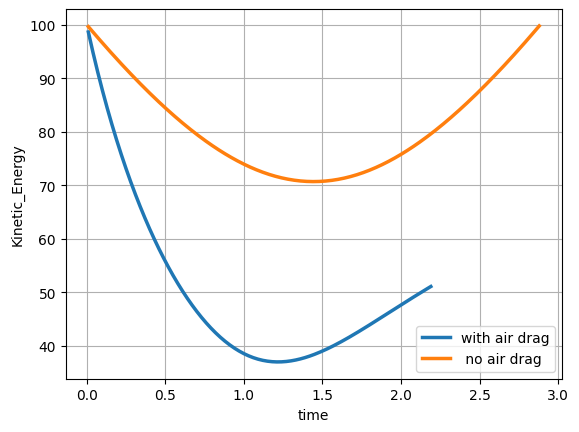

In [9]:
plt.plot(time,KE_drag,lw=2.5, label="with air drag")
plt.plot(time2,KE_no_drag,lw=2.5, label= ' no air drag')
plt.xlabel("time")
plt.ylabel("Kinetic_Energy")

plt.grid()
plt.legend()
plt.show()

## Energy loss Education 

In [16]:
energy_loss = KE_no_drag[-1] - KE_drag[-1]

print(f" Energy loss {energy_loss:.2f} jule")

 Energy loss 48.67 jule
